In [32]:
import ipdb
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import cartopy
import cartopy.crs as ccrs
from endgame import hist2d
from eod import msg
import datetime
import glob
import os
from scipy.stats import binned_statistic_2d
from scipy import stats
import pickle as pkl
from scipy.stats import gaussian_kde, linregress
import importlib
from utils import u_statistics as u_stats
from COCOON import shear_scaling_plots
importlib.reload(shear_scaling_plots)
from GLOBAL import glob_util

%matplotlib inline

In [1]:
cd ..

/users/global/cornkle/pythonWorkspace/proj_CEH


In [33]:
REGIONS = glob_util.REGIONS

In [38]:
dics = {}
for regs in MREGIONS.keys():
    isthere = 1
    for ids, y in enumerate(range(2000,2001)): #2021
        #'ipdb.set_trace()
        try:
            test = pd.read_csv(glob.glob('/prj/global_water/MCS_5000km2_tables_v2/'+regs+'/'+str(y)+'*.csv')[0])
        except:
            print(regs, 'not found')
            isthere = 0
            continue
    #      
        if ids == 0:
            test2 = pd.DataFrame(test)
        else :
            test2 = pd.concat([test2, test])
    if isthere == 0:
        continue
    else:
        dics[regs] = test2

InO not found


In [36]:
print(list(dics['WAf'].keys()))

['Unnamed: 0', 'date', 'month', 'hour', 'minute', 'year', 'day', 'area', 'area70', 'area60', 'area50', 'minlon', 'minlat', 'maxlon', 'maxlat', 'clon', 'clat', 'tminlon', 'tminlat', 'tmin', 'tmean', 'tp1', 'tp99', 'stormID', 'shape_complexity', 'major_axis_km', 'minor_axis_km', 'aspect_ratio', 'precipitation_mean', 'precipitation_max', 'precipitation_p95', 'precipitation_p99', 'precipitation_area1mm', 'precipitation_area3mm', 'precipitation_area10mm']


In [28]:
print(list(np.unique(test['month'])))

[np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


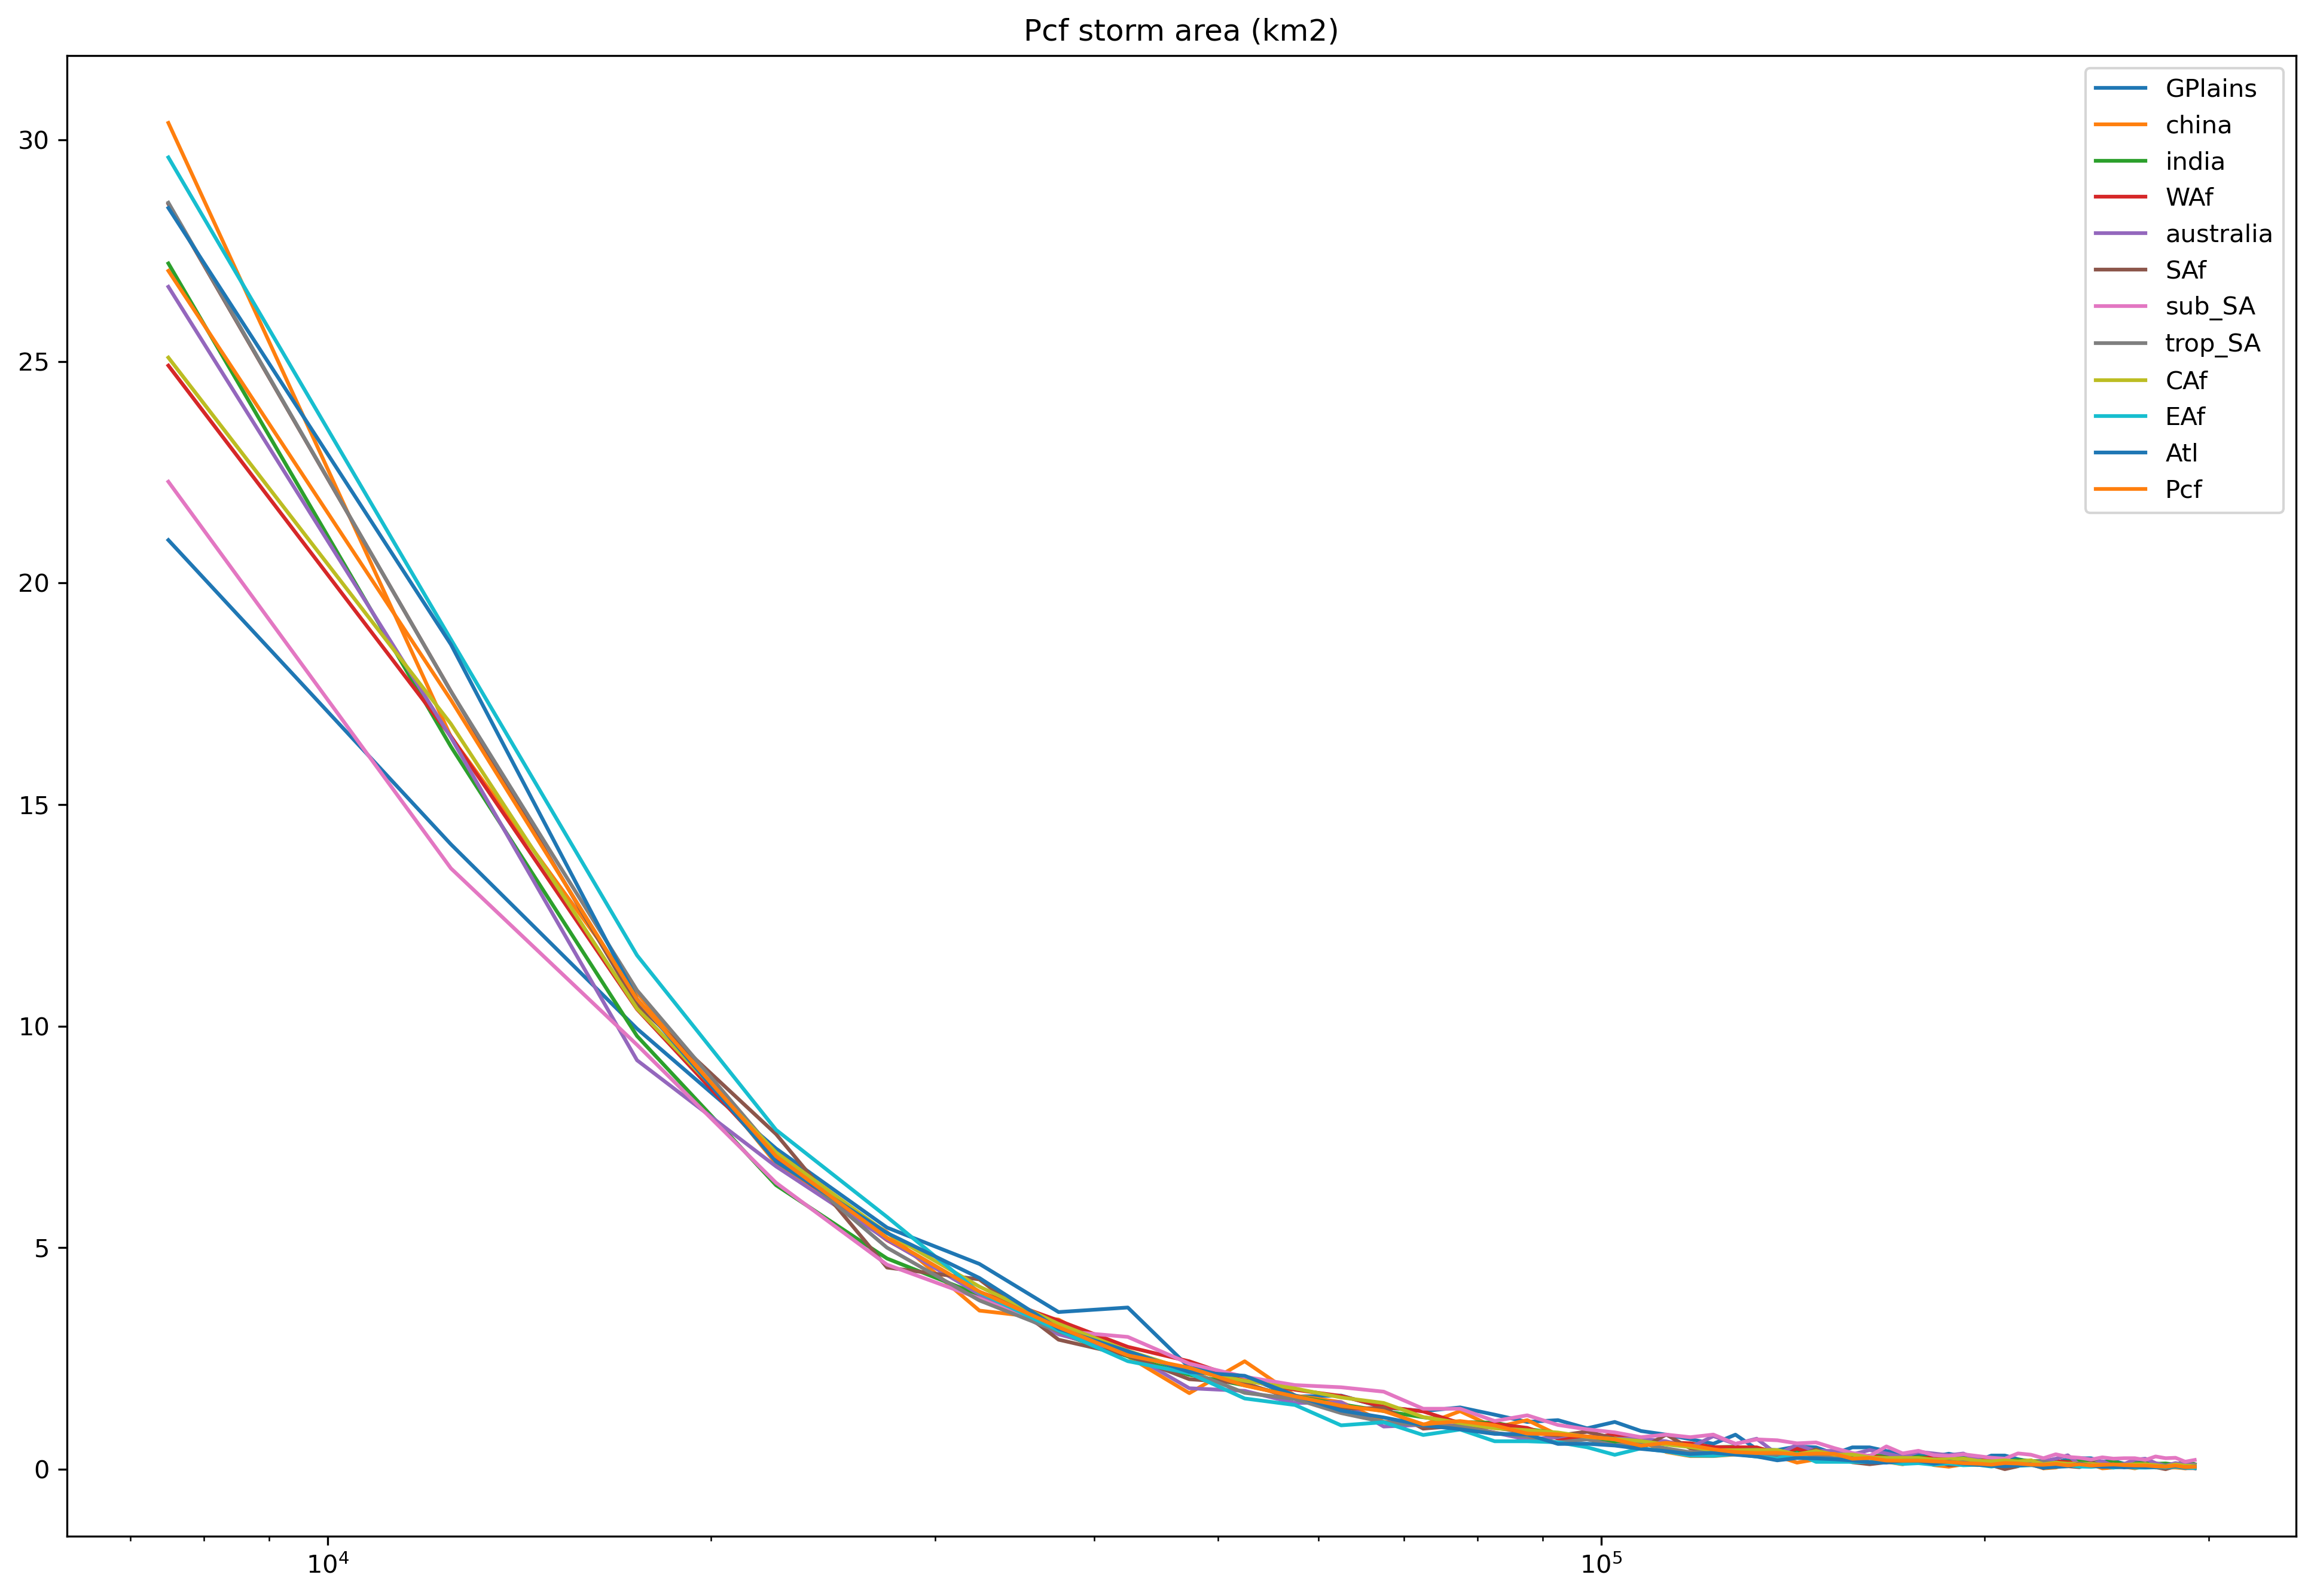

In [57]:
f= plt.figure(figsize=(13,9), dpi=300)

regs = 'WAf'

ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):

    pick = dics[regs]
    
    hist_freq, hist_count, bin_edge = u_stats.histo_frequency(pick['area'], bins=np.arange(5000,300000,5000))
    mid_bin = bin_edge[0:-1] + (bin_edge[1::]-bin_edge[0:-1])/2
    ax.plot(mid_bin,hist_freq, label= regs)

plt.legend()
ax.set_title(regs+' storm area (km2)')
plt.xscale('log')

plt.tight_layout()
#f.savefig(cnst.FIGS+'/LMCS/trackVSsnapshot/australia_trackVSsnapshot_area_histo.jpg')

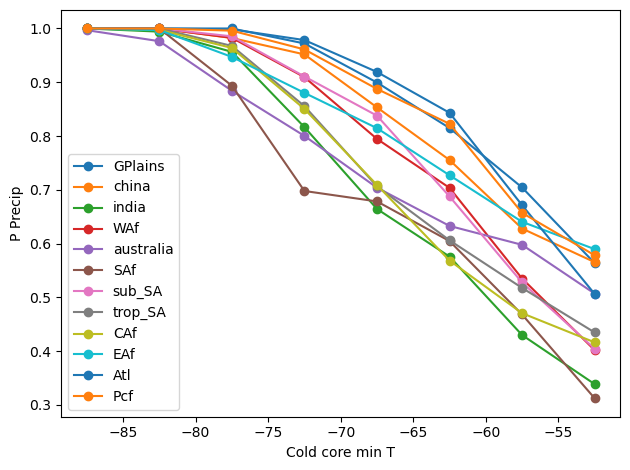

In [44]:
ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):
    outdic = hist2d.var2_binning_threshold((dics[regs]['tmin']).values, (dics[regs]['precipitation_max']).values, np.arange(-90,-40,5), gt=5)
    plt.plot(outdic['xbins'], outdic['y'], '-o', label=regs)
   
    ax.set_ylim(0,1)
plt.ylabel('P Precip')
plt.xlabel('Cold core min T')
plt.legend()
plt.tight_layout()

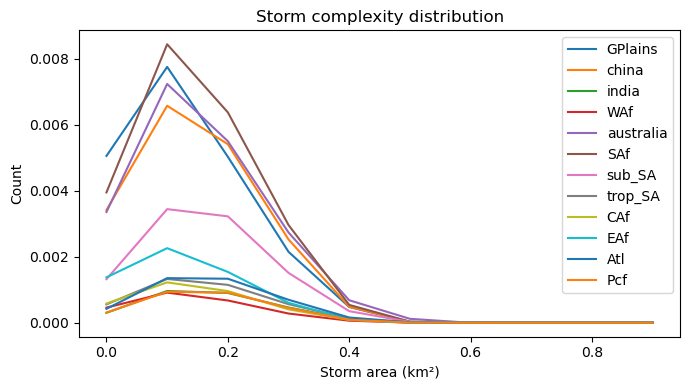

In [56]:
bins = np.linspace(0,1.1,11)

plt.figure(figsize=(7,4))
for ids, regs in enumerate(dics.keys()):
    hist, count, hbins = u_stats.histo_frequency(dics[regs]['shape_complexity'], bins=bins)

    #ipdb.set_trace()
    xbins = hbins[0:-1] + (hbins[1::]-hbins[0:-1])/2

    plt.plot(np.arange(0,1,0.1), hist/np.sum(count), label=regs)
    
plt.legend()

plt.xlabel("Storm area (km²)")
plt.ylabel("Count")
plt.title("Storm complexity distribution")
plt.tight_layout()
plt.show()

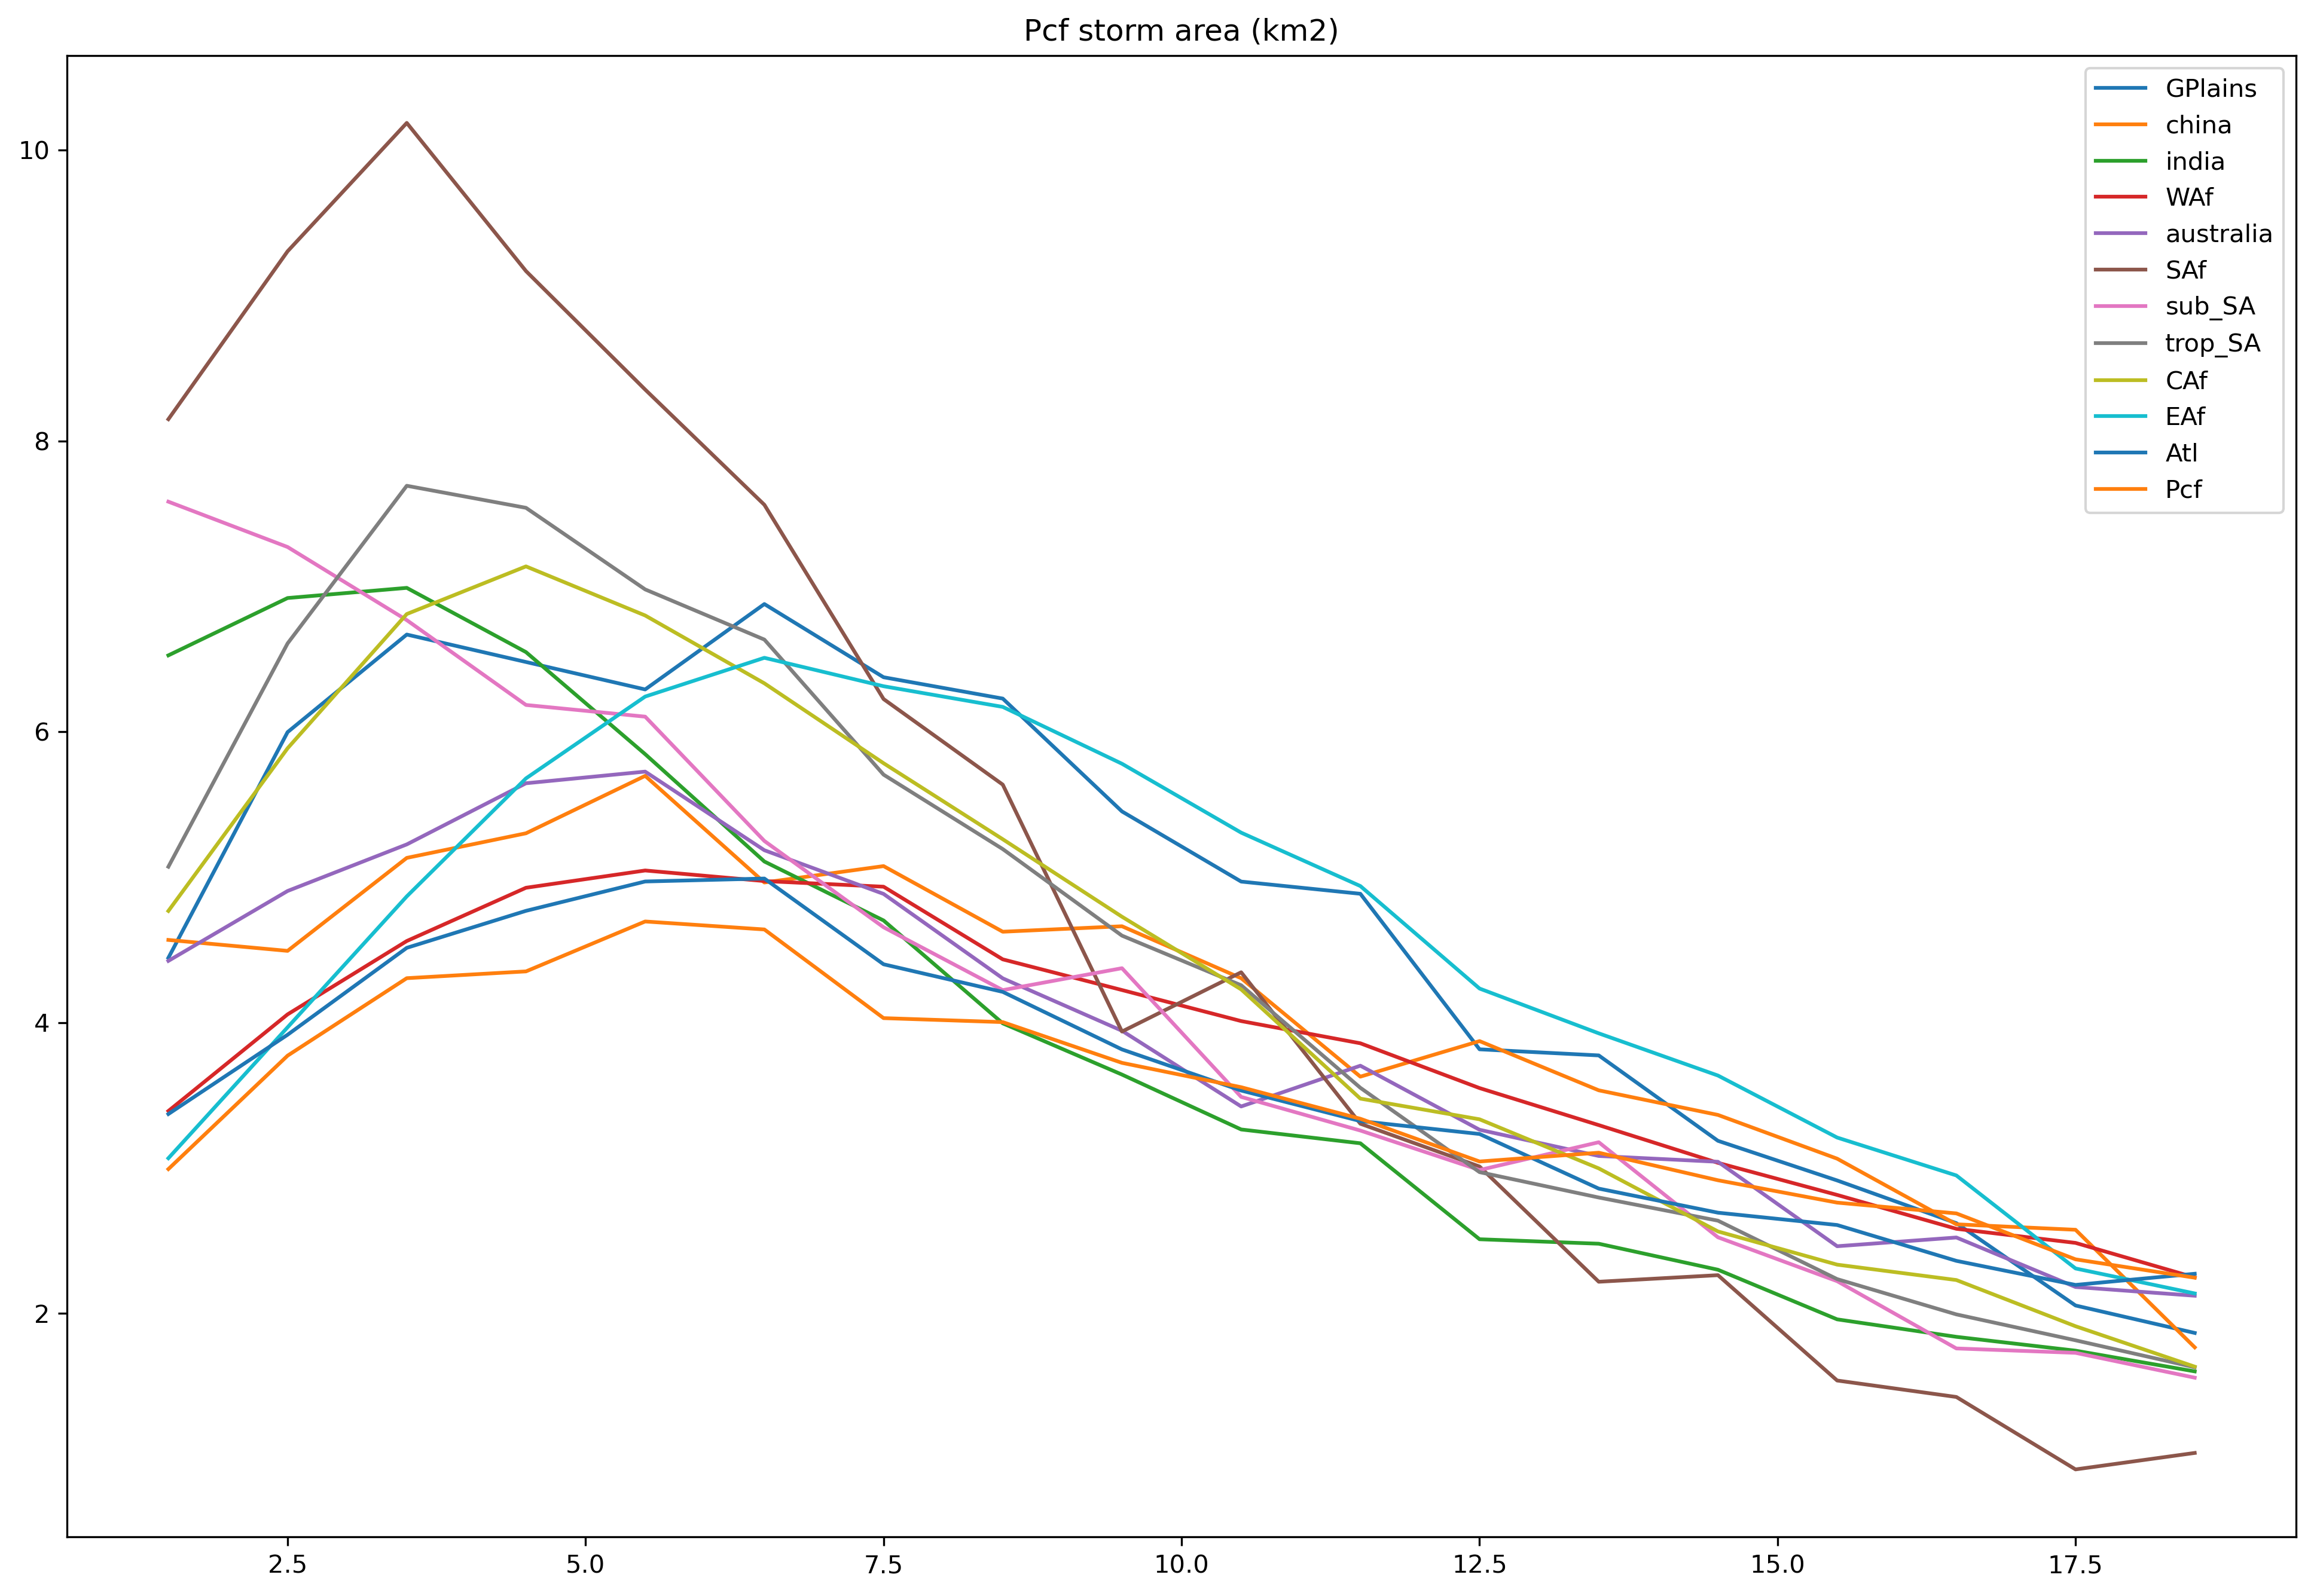

In [62]:
f= plt.figure(figsize=(13,9), dpi=300)

ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):

    pick = dics[regs]
    pick = pick[pick['shape_complexity']<0.5]
    
    hist_freq, hist_count, bin_edge = u_stats.histo_frequency(pick['precipitation_max'], bins=np.arange(1,20,1))
    mid_bin = bin_edge[0:-1] + (bin_edge[1::]-bin_edge[0:-1])/2
    ax.plot(mid_bin,hist_freq, label= regs)

plt.legend()
ax.set_title(regs+' storm area (km2)')

plt.tight_layout()

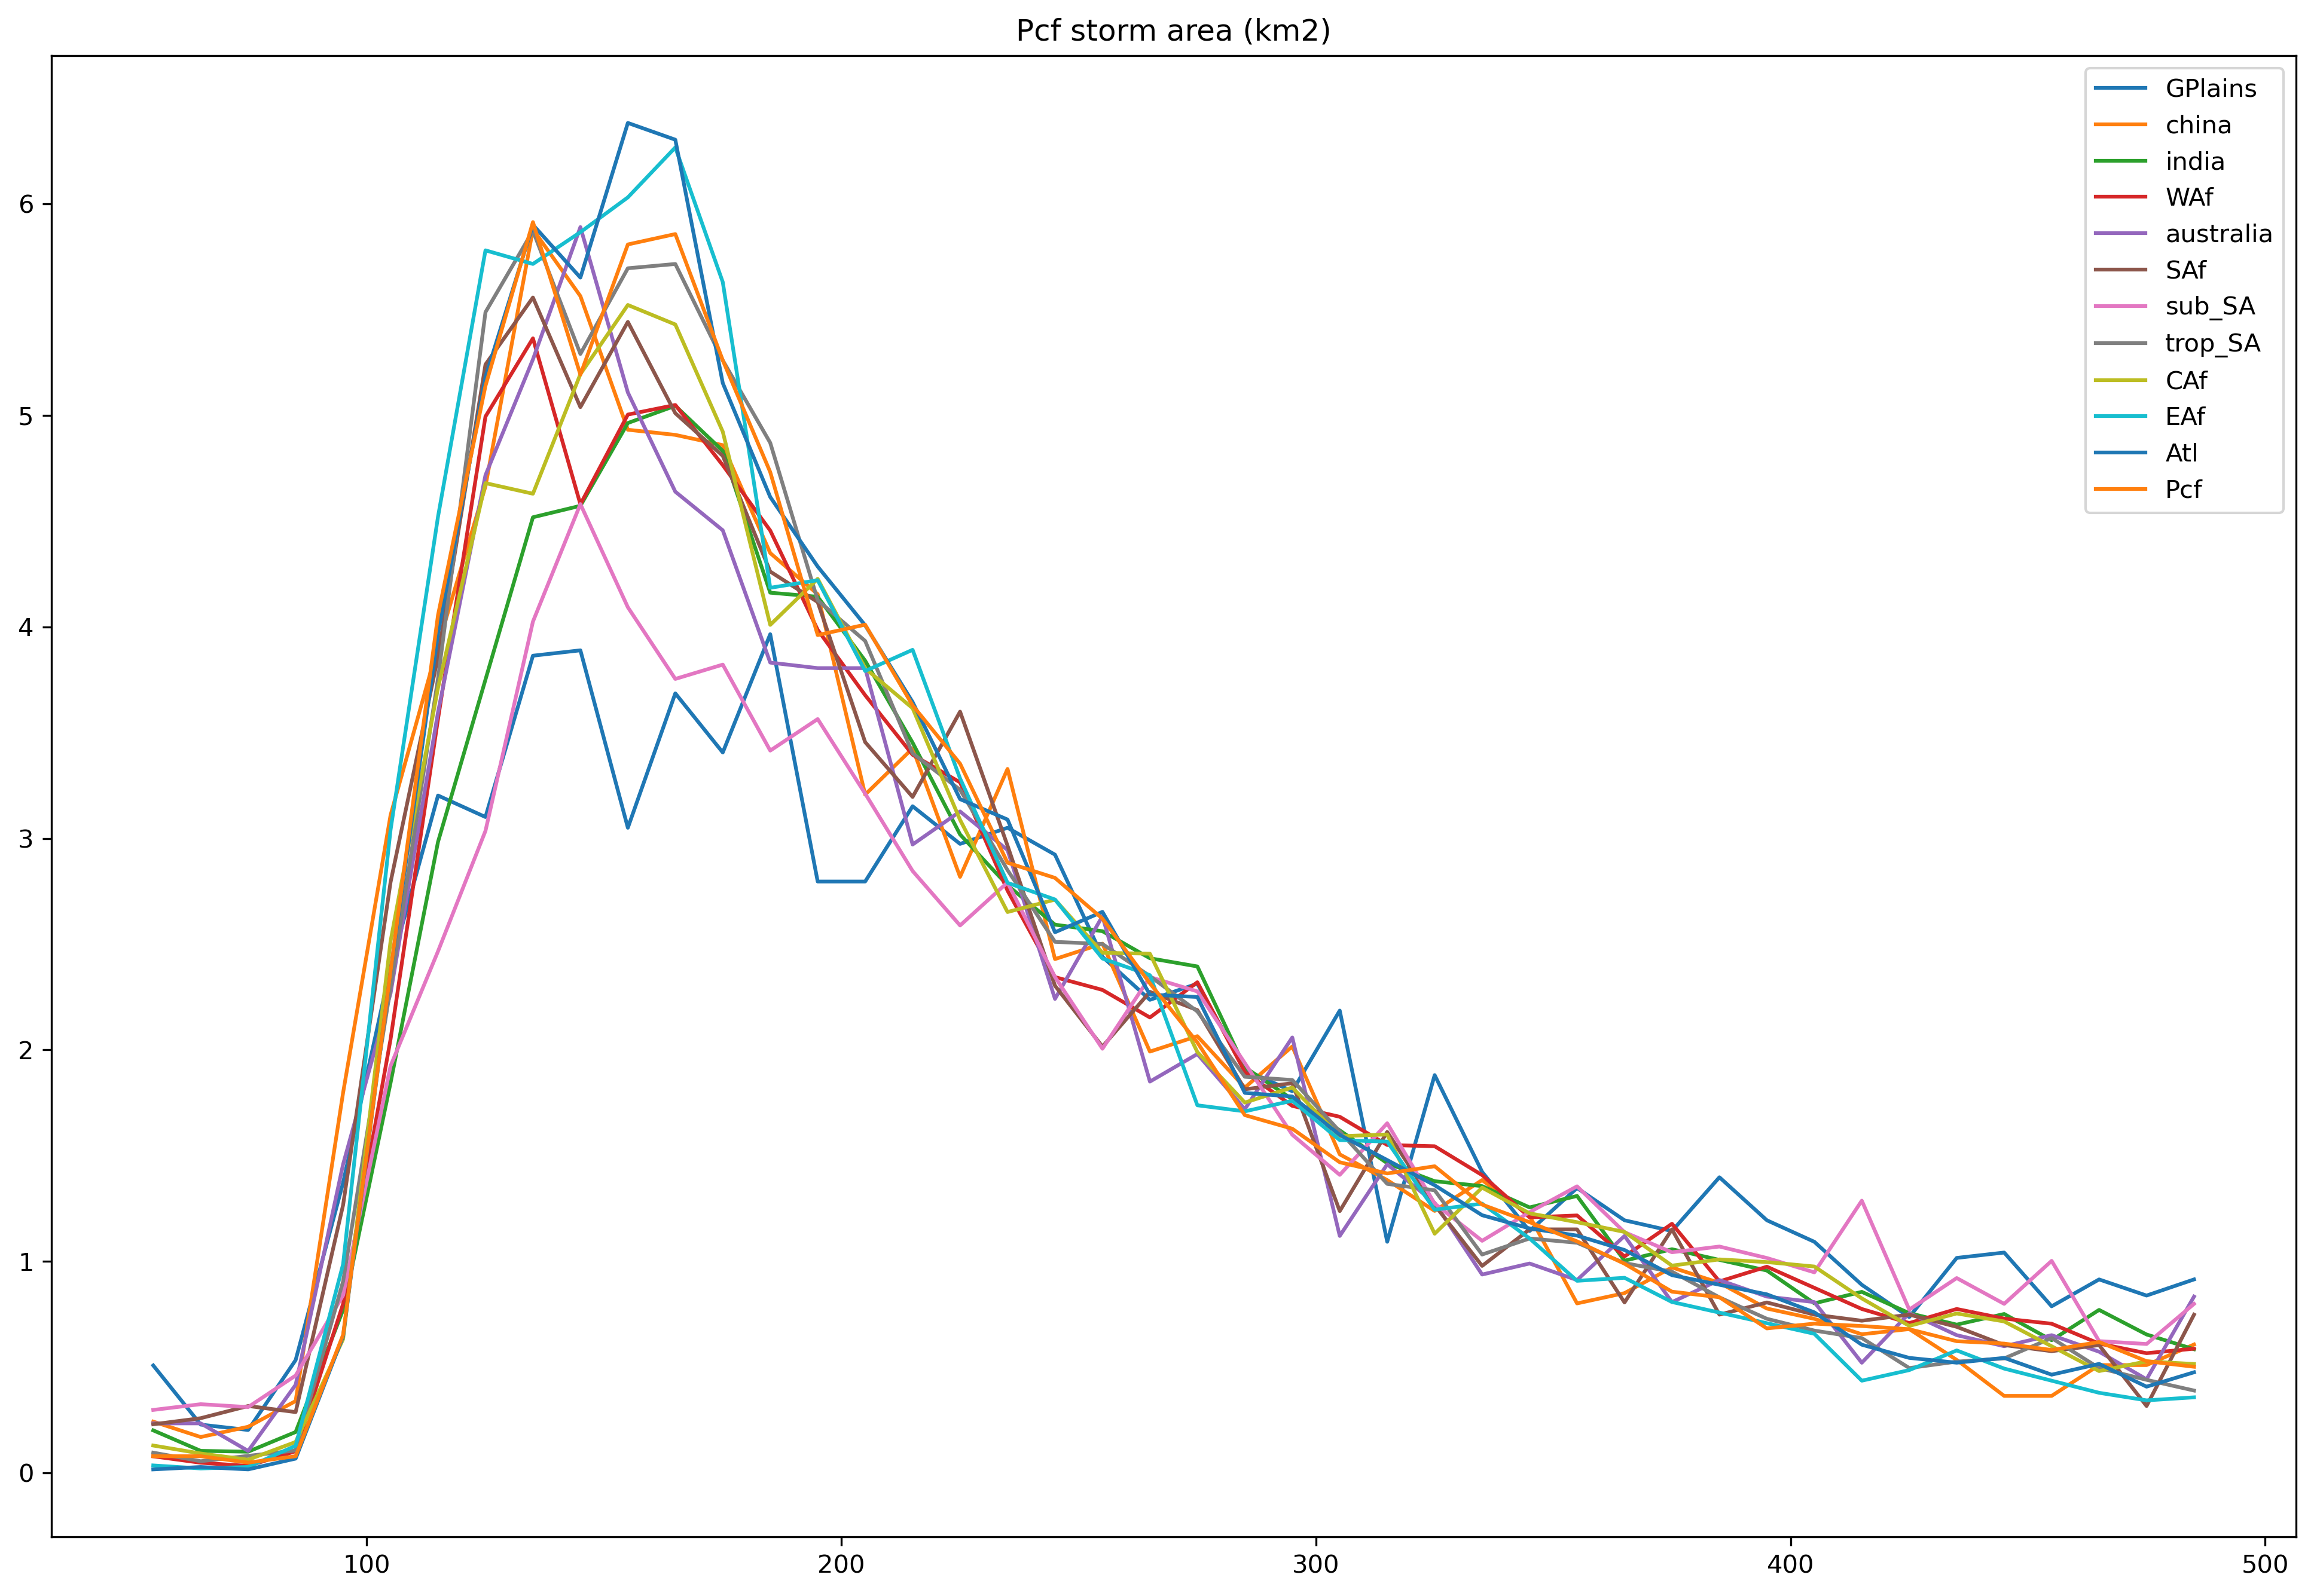

In [66]:
f= plt.figure(figsize=(13,9), dpi=300)

ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):

    pick = dics[regs]
    pick = pick[pick['shape_complexity']<0.3]
    
    hist_freq, hist_count, bin_edge = u_stats.histo_frequency(pick['major_axis_km'], bins=np.arange(50,500,10))
    mid_bin = bin_edge[0:-1] + (bin_edge[1::]-bin_edge[0:-1])/2
    ax.plot(mid_bin,hist_freq, label= regs)

plt.legend()
ax.set_title(regs+' storm area (km2)')

plt.tight_layout()

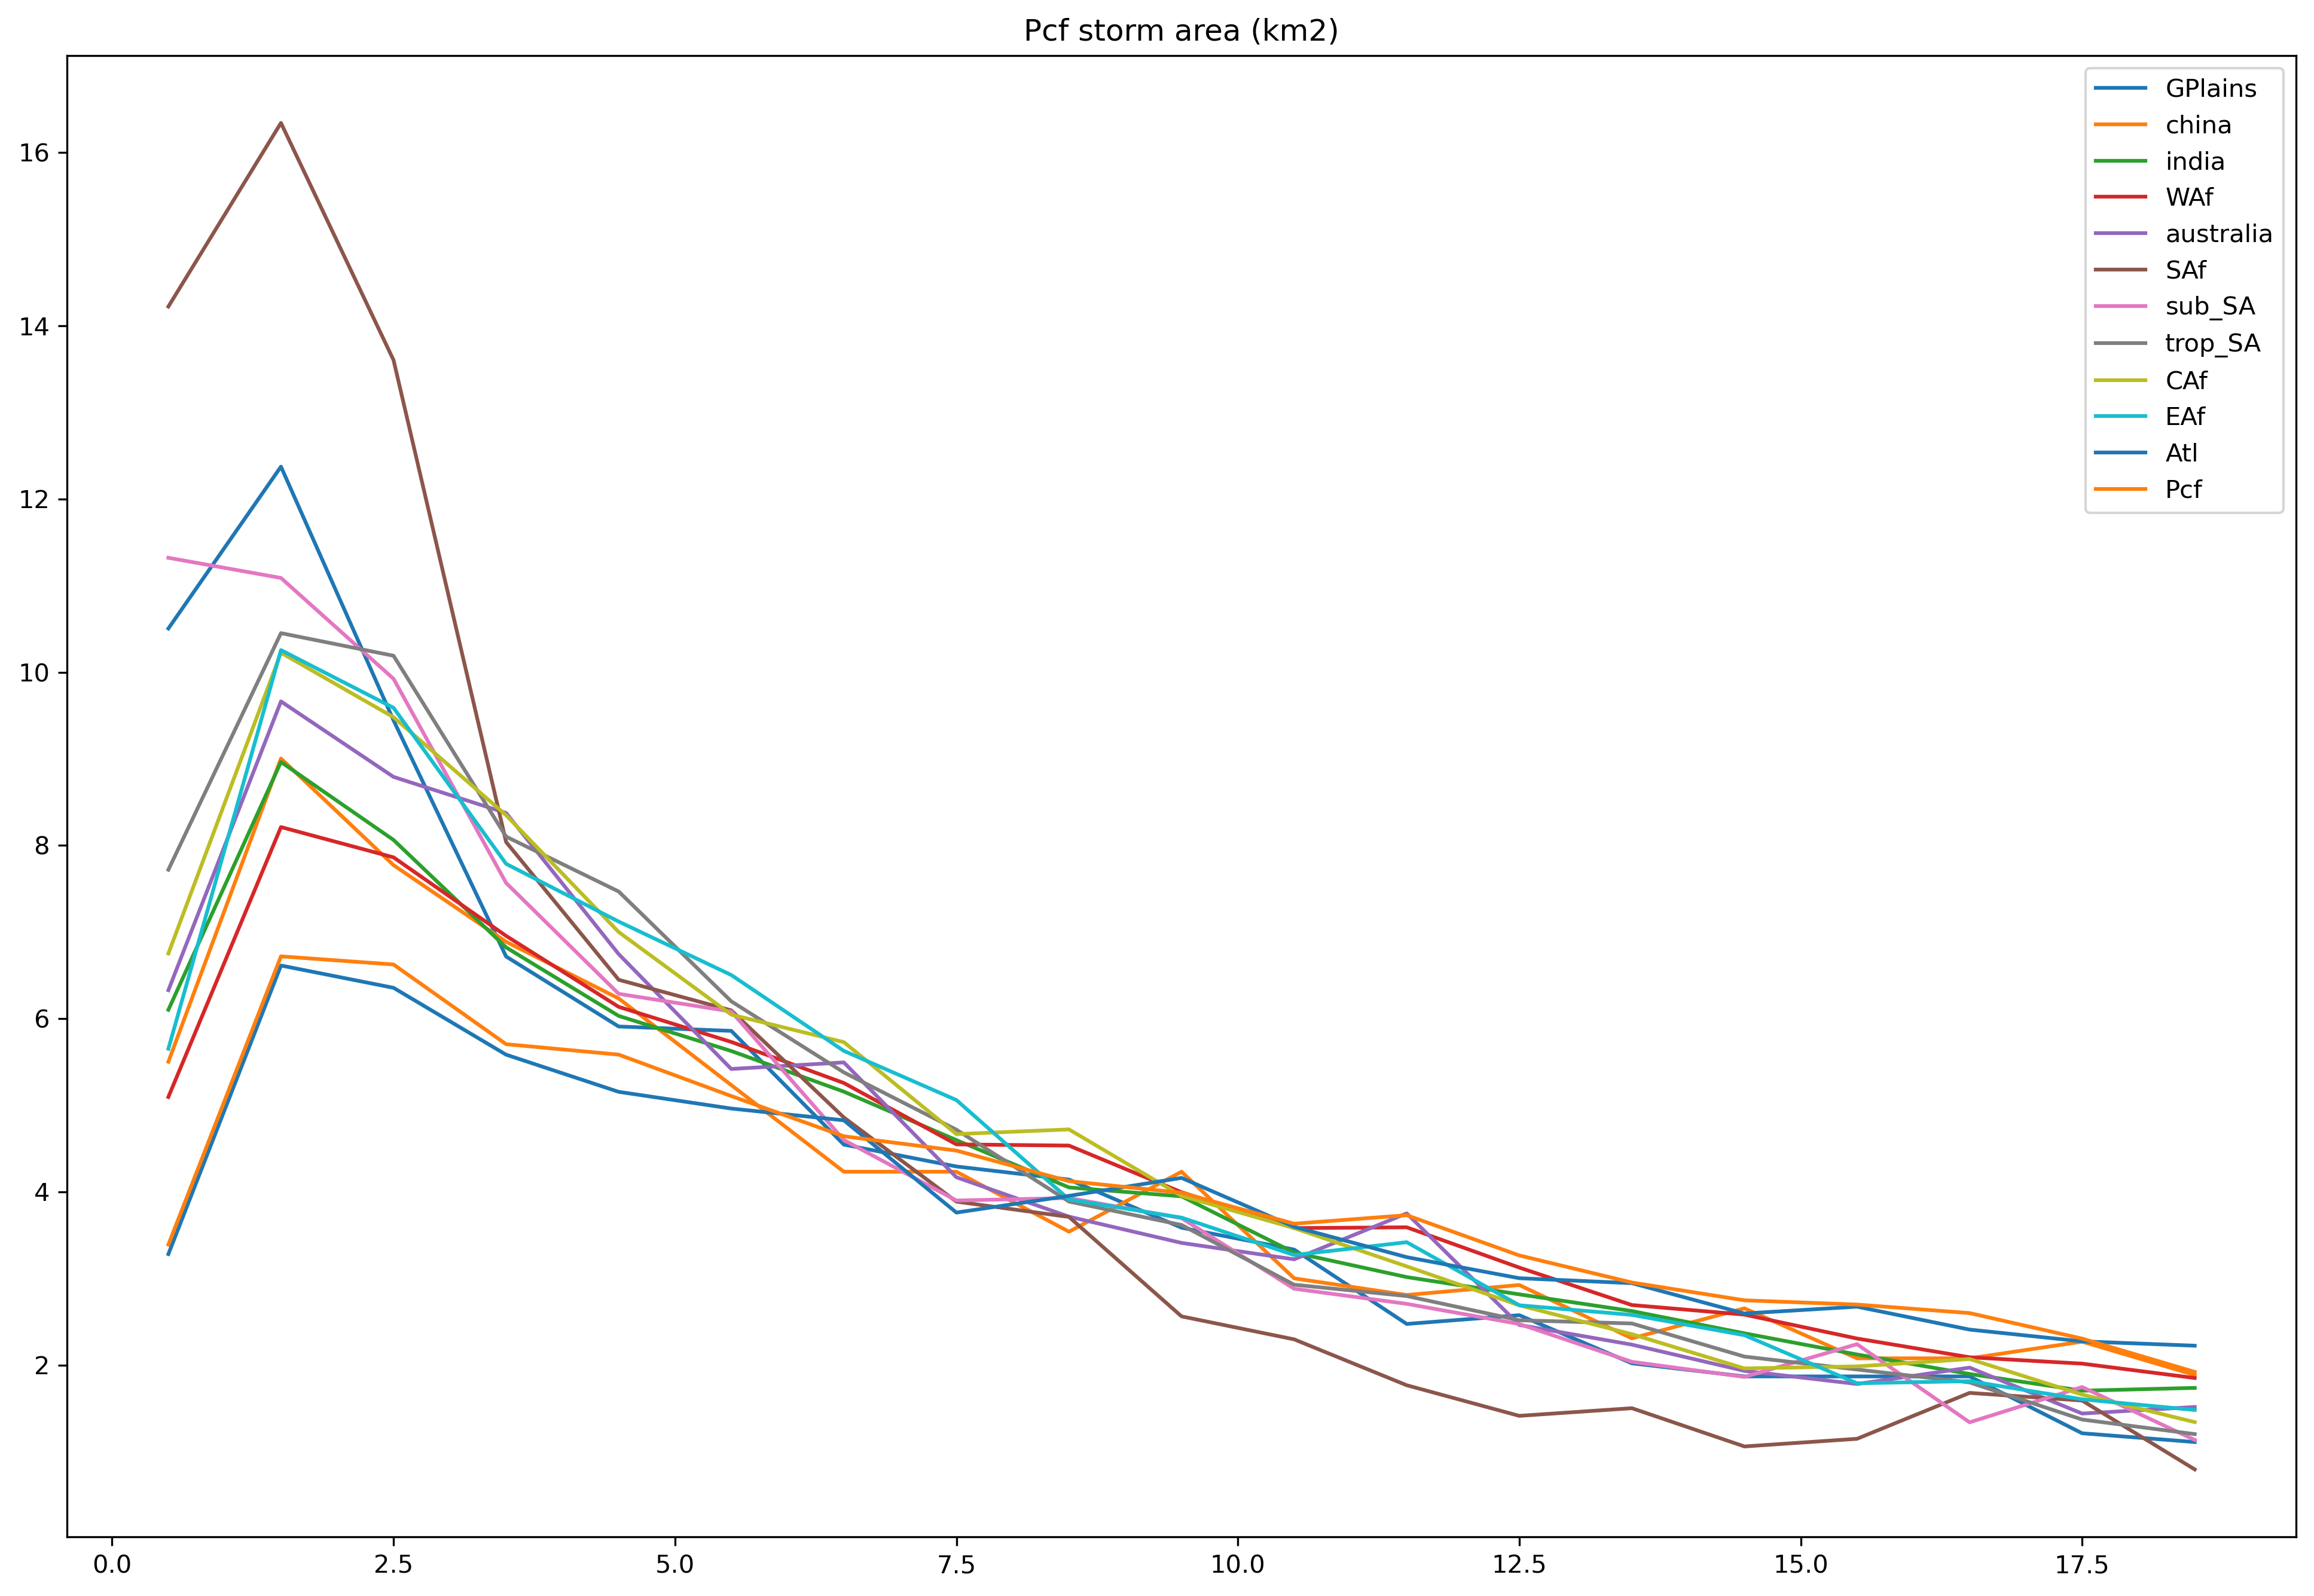

In [77]:
f= plt.figure(figsize=(13,9), dpi=300)

ax = f.add_subplot(111)
for ids, regs in enumerate(dics.keys()):

    pick = dics[regs]
    pick = pick[pick['precipitation_max']>=10]
    
    hist_freq, hist_count, bin_edge = u_stats.histo_frequency(pick['precipitation_area10mm']/pick['precipitation_area1mm']*100, bins=np.arange(0,20,1))
    mid_bin = bin_edge[0:-1] + (bin_edge[1::]-bin_edge[0:-1])/2
    ax.plot(mid_bin,hist_freq, label= regs)

plt.legend()
ax.set_title(regs+' storm area (km2)')

plt.tight_layout()